In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("network_intrusion_data.csv")
df.shape

Saving network_intrusion_data.csv to network_intrusion_data.csv


(1341, 15)

In [3]:
df.head()

,attack_neptune,attack_normal,attack_satan,count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_same_srv_rate,dst_host_srv_count,flag_S0,flag_SF,last_flag,logged_in,same_srv_rate,serror_rate,service_http
0,0,1,0,1,1.00,0.000000,0.000000,0,0,0,NaN,0,0.000000,0.0,0
1,0,1,0,1,1.00,0.500000,0.500000,1,0,1,S,0,0.500000,0.0,1
2,0,1,0,1,1.00,0.333333,0.333333,2,0,0,SA,0,0.333333,0.0,0
3,0,1,0,2,0.75,0.500000,0.500000,2,0,0,A,0,0.500000,0.0,1
4,0,1,0,3,0.60,0.600000,0.600000,2,0,0,PA,0,0.600000,0.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   attack_neptune               1341 non-null   int64  
 1   attack_normal                1341 non-null   int64  
 2   attack_satan                 1341 non-null   int64  
 3   count                        1341 non-null   int64  
 4   dst_host_diff_srv_rate       1341 non-null   float64
 5   dst_host_same_src_port_rate  1341 non-null   float64
 6   dst_host_same_srv_rate       1341 non-null   float64
 7   dst_host_srv_count           1341 non-null   int64  
 8   flag_S0                      1341 non-null   int64  
 9   flag_SF                      1341 non-null   int64  
 10  last_flag                    1288 non-null   object 
 11  logged_in                    1341 non-null   int64  
 12  same_srv_rate                1341 non-null   float64
 13  serror_rate       

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print(missing_summary)

           missing_count  missing_percent
last_flag             53         3.952274


In [6]:
print(df.describe(include="all"))

        attack_neptune  attack_normal  attack_satan        count  \
count           1341.0         1341.0        1341.0  1341.000000   
unique             NaN            NaN           NaN          NaN   
top                NaN            NaN           NaN          NaN   
freq               NaN            NaN           NaN          NaN   
mean               0.0            1.0           0.0    51.580164   
std                0.0            0.0           0.0    51.798423   
min                0.0            1.0           0.0     1.000000   
25%                0.0            1.0           0.0    10.000000   
50%                0.0            1.0           0.0    32.000000   
75%                0.0            1.0           0.0    78.000000   
max                0.0            1.0           0.0   212.000000   

        dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
count              1341.000000                  1341.000000   
unique                     NaN                          N

In [7]:
attack_cols = ["attack_neptune", "attack_normal", "attack_satan"]
print("Class distribution:")
print(df[attack_cols].sum())

constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]
print("\nConstant columns:", constant_cols)


Class distribution:
attack_neptune       0
attack_normal     1341
attack_satan         0
dtype: int64

Constant columns: ['attack_neptune', 'attack_normal', 'attack_satan', 'flag_S0', 'logged_in', 'serror_rate']


In [8]:
print(df["last_flag"].value_counts(dropna=False))

last_flag
A      729
PA     544
NaN     53
S        8
SA       2
FPA      2
FA       2
R        1
Name: count, dtype: int64


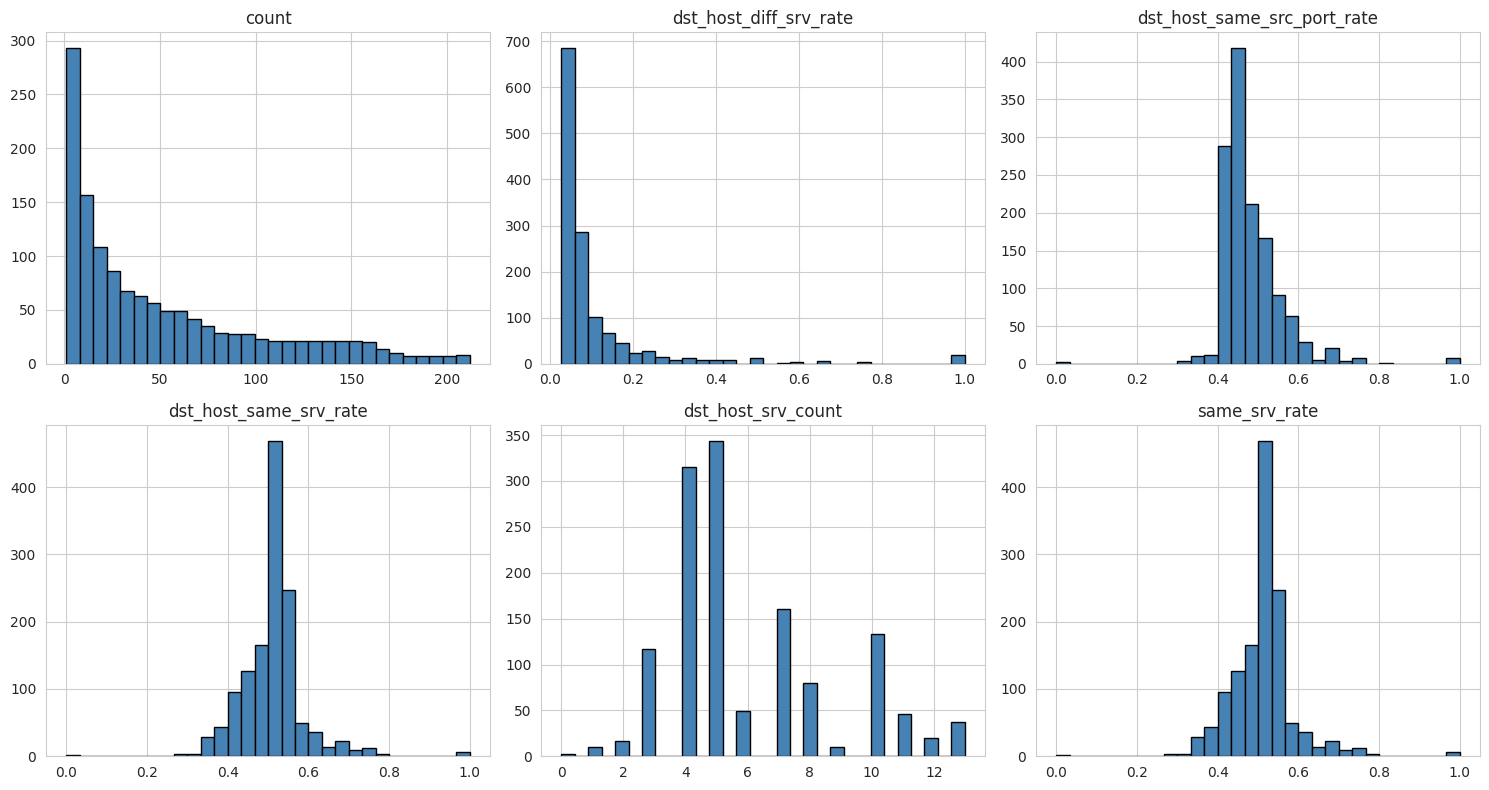

In [9]:
numeric_cols = ["count", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
                 "dst_host_same_srv_rate", "dst_host_srv_count", "same_srv_rate"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

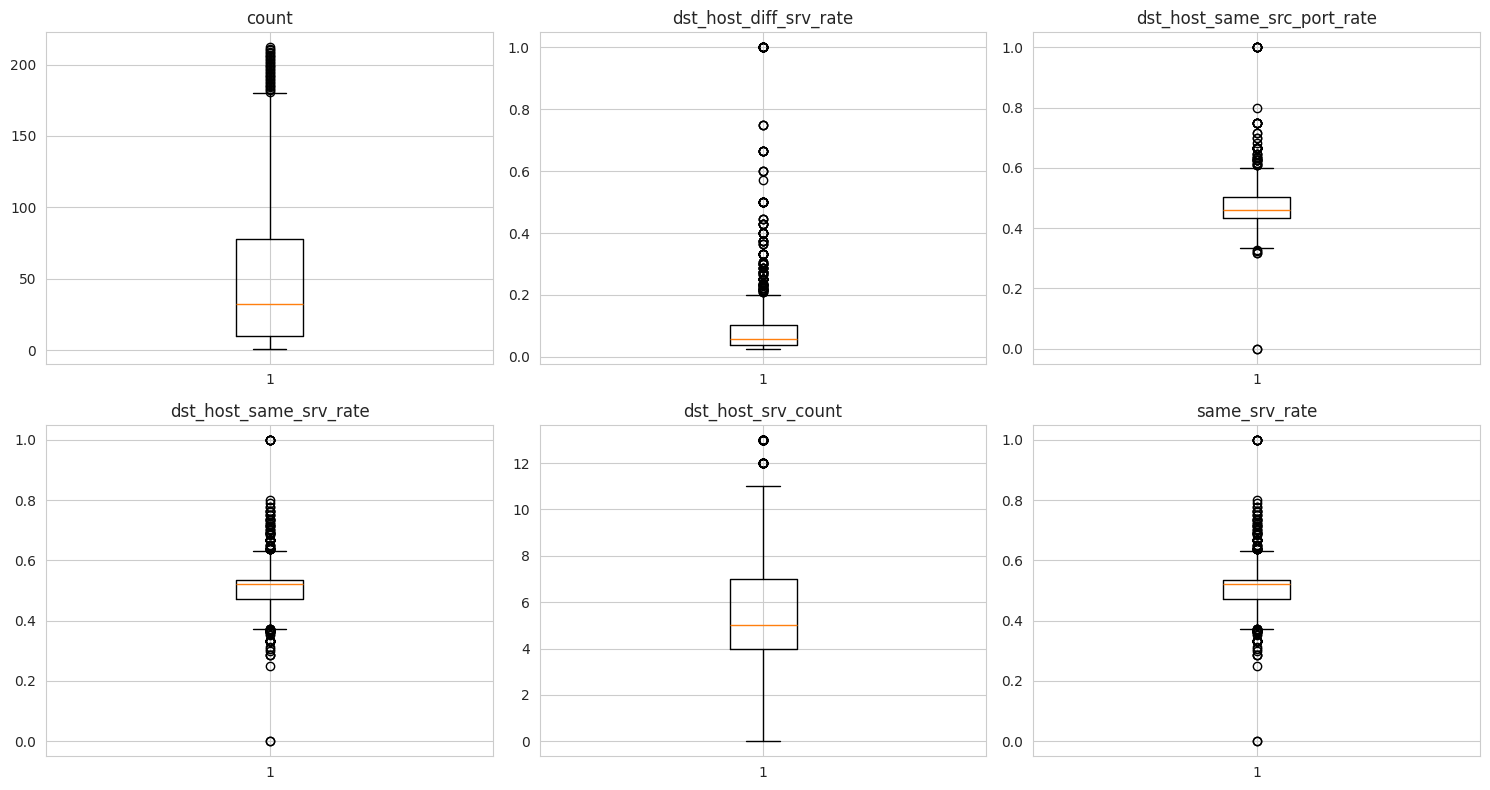

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

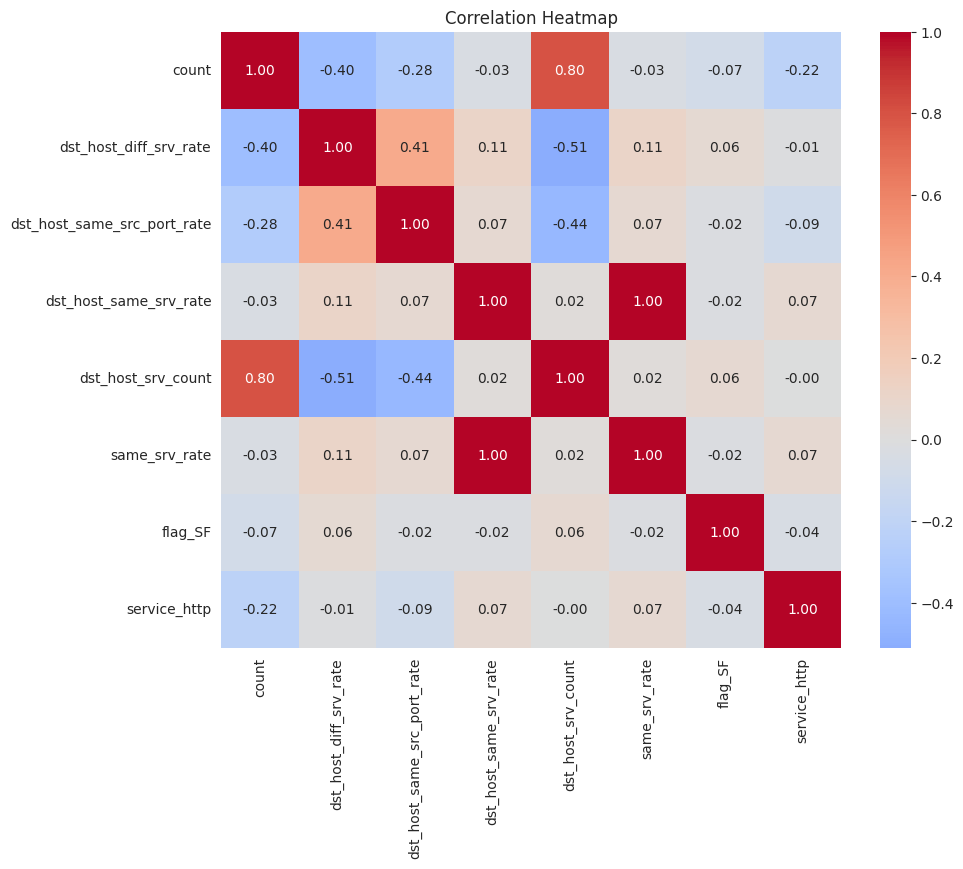

In [11]:
corr_cols = numeric_cols + ["flag_SF", "service_http"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

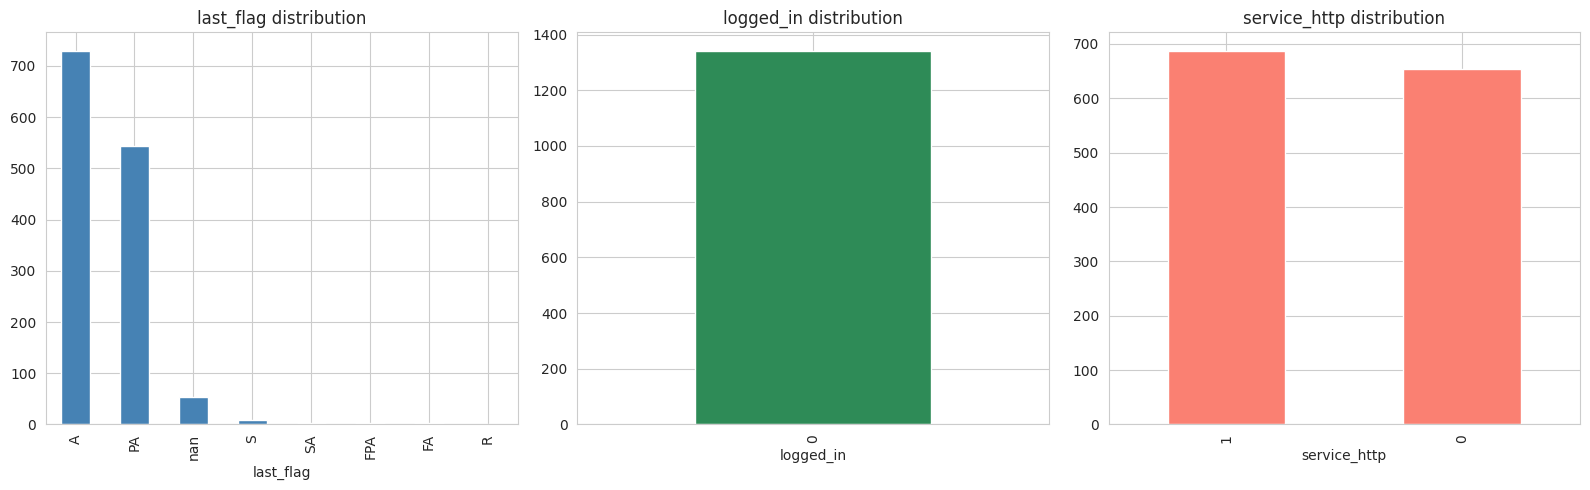

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df["last_flag"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("last_flag distribution")

df["logged_in"].value_counts().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("logged_in distribution")

df["service_http"].value_counts().plot(kind="bar", ax=axes[2], color="salmon")
axes[2].set_title("service_http distribution")

plt.tight_layout()
plt.show()

In [13]:
df_clean = df.drop(columns=["attack_neptune", "attack_satan", "flag_S0", "logged_in", "serror_rate", "attack_normal"])

df_clean["last_flag"] = df_clean["last_flag"].fillna(df_clean["last_flag"].mode()[0])

df_clean = df_clean.drop(columns=["dst_host_same_srv_rate"])

print(df_clean.shape)
print(df_clean.isnull().sum())

(1341, 8)
count                          0
dst_host_diff_srv_rate         0
dst_host_same_src_port_rate    0
dst_host_srv_count             0
flag_SF                        0
last_flag                      0
same_srv_rate                  0
service_http                   0
dtype: int64


In [14]:
le = LabelEncoder()
df_clean["last_flag"] = le.fit_transform(df_clean["last_flag"])

print(dict(zip(le.classes_, le.transform(le.classes_))))
df_clean.head()

{'A': np.int64(0), 'FA': np.int64(1), 'FPA': np.int64(2), 'PA': np.int64(3), 'R': np.int64(4), 'S': np.int64(5), 'SA': np.int64(6)}


,count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_count,flag_SF,last_flag,same_srv_rate,service_http
0,1,1.00,0.000000,0,0,0,0.000000,0
1,1,1.00,0.500000,1,1,5,0.500000,1
2,1,1.00,0.333333,2,0,6,0.333333,0
3,2,0.75,0.500000,2,0,0,0.500000,1
4,3,0.60,0.600000,2,0,3,0.600000,1


In [15]:
scale_cols = ["count", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
              "dst_host_srv_count", "same_srv_rate"]

scaler = StandardScaler()
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

df_clean.describe()

,count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_count,flag_SF,last_flag,same_srv_rate,service_http
count,1.341000e+03,1341.000000,1.341000e+03,1.341000e+03,1341.000000,1341.000000,1.341000e+03,1341.000000
mean,6.358324e-17,0.000000,-4.662771e-16,4.238883e-17,0.005966,1.263236,-1.420026e-15,0.512304
std,1.000373e+00,1.000373,1.000373e+00,1.000373e+00,0.077036,1.509689,1.000373e+00,0.500035
min,-9.768451e-01,-0.533466,-6.254158e+00,-2.249057e+00,0.000000,0.000000,-6.322096e+00,0.000000
25%,-8.030298e-01,-0.458740,-5.922910e-01,-7.565490e-01,0.000000,0.000000,-4.945228e-01,0.000000
50%,-3.781480e-01,-0.320718,-2.565319e-01,-3.834220e-01,0.000000,0.000000,1.439257e-01,1.000000
75%,5.102413e-01,-0.018865,2.965267e-01,3.628319e-01,0.000000,3.000000,3.130305e-01,1.000000
max,3.098158e+00,6.018201,6.787660e+00,2.601594e+00,1.000000,6.000000,6.051518e+00,1.000000


In [16]:
df_clean.to_csv("network_intrusion_preprocessed.csv", index=False)
print("Saved:", df_clean.shape)

Saved: (1341, 8)


In [17]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"\nDataset shape: {df.shape}")
print(f"Total records: {df.shape[0]}, Total features: {df.shape[1]}")

print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    for col, val in missing.items():
        print(f"{col}: {val} missing ({val / len(df) * 100:.2f}%)")
else:
    print("No missing values")

print("\n--- Target Class Distribution ---")
print(df[["attack_neptune", "attack_normal", "attack_satan"]].sum())

print("\n--- Constant Columns (zero variance) ---")
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]
print(constant_cols)

print("\n--- Numeric Feature Ranges ---")
numeric_summary = df[numeric_cols].agg(["min", "max", "mean", "std"]).T
print(numeric_summary)

print("\n--- Categorical Feature: last_flag ---")
print(df["last_flag"].value_counts(dropna=False))

print("\n--- Highly Correlated Feature Pairs (|corr| > 0.7) ---")
corr = df[corr_cols].corr()
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 2)))
for pair in high_corr:
    print(pair)

print("\n--- Preprocessing Steps Applied ---")
print("1. Dropped constant columns: attack_neptune, attack_satan, flag_S0, logged_in, serror_rate, attack_normal")
print("2. Filled missing last_flag values with mode")
print("3. Dropped redundant column: dst_host_same_srv_rate (perfectly correlated with same_srv_rate)")
print("4. Label encoded last_flag")
print("5. Standard scaled numeric features")
print(f"\nFinal preprocessed shape: {df_clean.shape}")

EDA SUMMARY

Dataset shape: (1341, 15)
Total records: 1341, Total features: 15

--- Missing Values ---
last_flag: 53 missing (3.95%)

--- Target Class Distribution ---
attack_neptune       0
attack_normal     1341
attack_satan         0
dtype: int64

--- Constant Columns (zero variance) ---
['attack_neptune', 'attack_normal', 'attack_satan', 'flag_S0', 'logged_in', 'serror_rate']

--- Numeric Feature Ranges ---
                                  min    max       mean        std
count                        1.000000  212.0  51.580164  51.798423
dst_host_diff_srv_rate       0.026066    1.0   0.105368   0.148710
dst_host_same_src_port_rate  0.000000    1.0   0.479546   0.076705
dst_host_same_srv_rate       0.000000    1.0   0.510934   0.080847
dst_host_srv_count           0.000000   13.0   6.027591   2.681053
same_srv_rate                0.000000    1.0   0.510934   0.080847

--- Categorical Feature: last_flag ---
last_flag
A      729
PA     544
NaN     53
S        8
SA       2
FPA      2
